In [1]:
import sys
sys.path.append("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/utils") 
os.chdir("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro")
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import matplotlib.pyplot as plt
# from utils.custom import plotting

In [2]:
import numpy as np
from matplotlib import cm
import matplotlib as mpl
import matplotlib.pyplot as plt

def justify(a, invalid_val=np.nan, axis=1, side='right'):
    """
    Justifies a 2D array
    Courtesy: https://stackoverflow.com/questions/44558215/python-justifying-numpy-array/44559180#44559180

    Parameters
    ----------
    A : ndarray
        Input array to be justified
    axis : int
        Axis along which justification is to be made
    side : str
        Direction of justification. It could be 'left', 'right', 'up', 'down'
        It should be 'left' or 'right' for axis=1 and 'up' or 'down' for axis=0.

    """
    if invalid_val is np.nan:
        mask = ~np.isnan(a)
    else:
        mask = a!=invalid_val
    justified_mask = np.sort(mask,axis=axis)
    if (side=='up') | (side=='left'):
        justified_mask = np.flip(justified_mask,axis=axis)
    out = np.full(a.shape, invalid_val)
    if axis==1:
        out[justified_mask] = a[mask]
    else:
        out.T[justified_mask.T] = a.T[mask.T]
    return out

def summa_layers_plot(var, depth, ax=None, colormap='viridis', plot_soil=True,
           plot_snow=True, variable_range=None, add_colorbar=True,
           line_kwargs={}, cbar_kwargs={}):
    """
    Makes a layers plot. Example usage:

    ::

        import pysumma.plotting as psp
        time_range = slice('10-29-2000', '04-30-2001')
        depth    = ds.isel(hru=0).sel(time=time_range)['iLayerHeight']
        temp     = ds.isel(hru=0).sel(time=time_range)['mLayerTemp']
        psp.layers(temp, depth)

    Parameters
    ----------
    var: xr.DataArray
        The variable holding the data to plot.
        Typically begins with ``mLayer``.
    depth: xr.DataArray
        The variable defining the depths of the interfaces
        of each layer. Typically should be ``iLayerHeight``
    ax: Axes
        The axis to plot on. If none is given, a new axis
        will be created
    colormap: string, default='viridis'
        The colormap to use
    plot_soil: boolean, default=True
        Whether to plot the soil domain
    plot_snow: boolean, default=True
        Whether to plot the snow domain
    variable_range: List[float], default=variable range
        The range of numerical values to use. Must be two numbers.
    add_colorbar: boolean, default=True
        Whether to add a colorbar
    line_kwargs: Dict, default={}
        Keyword arguments to pass to ax.vlines.
        These draw the individual layers.
    cbar_kwargs: Dict, default={}
        Keyword arguments to draw the colorbar.
        They are passed directly to plt.colorbar.
    """
    # Preprocess the data
    vmask = var != -9999
    dmask = depth != -9999
    depth.values = justify(depth.where(dmask).values)
    var.values = justify(var.where(vmask).values)
    lo_depth = depth.where(depth > 0).T
    hi_depth = depth.where(depth < 0).T
    if plot_soil and not plot_snow:
        var = var.where((depth > 0).values[:,:-1]).T
    elif plot_snow and not plot_soil:
        var = var.where((depth < 0).values[:,:-1]).T
    else:
        var = var.T
    time = depth.time.values

    # Map colors to full range of data
    if variable_range is not None:
        assert len(variable_range) == 2, 'variable_range must have 2 values!'
        norm = plt.Normalize(variable_range[0], variable_range[1])
    else:
        norm = plt.Normalize(np.nanmin(var), np.nanmax(var))
    cmap = mpl.colormaps[colormap]
    rgba = cmap(norm(var))

    # Create axes if needed
    if not ax:
        fig, ax = plt.subplots(figsize=(9,4))

    # Plot soil layers - need to reverse because we plot bottom down
    if plot_soil:
        for l in lo_depth.ifcToto.values[:-1][::-1]:
            y = lo_depth[l]
            y[np.isnan(y)] = 0
            ax.vlines(time, ymin=-y, ymax=0, color=rgba[l], **line_kwargs)

    # Plot snow layers - plot top down
    if plot_snow:
        for l in hi_depth.ifcToto.values[:-1]:
            y = hi_depth[l]
            y[np.isnan(y)] = 0
            if (y != 0).any():
                ax.vlines(time, ymin=0, ymax=-y, color=rgba[l], **line_kwargs)

    # Add the colorbar
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(var.values.flatten())
    try:
        label = var.long_name
    except:
        label = var.name
    if 'label' not in cbar_kwargs.keys():
        cbar_kwargs['label'] = label
    if 'ax' not in cbar_kwargs.keys():
        cbar_kwargs['ax'] = ax
    if add_colorbar:
        plt.gcf().colorbar(mappable, **cbar_kwargs)
    return ax, mappable

In [3]:
# figure for ross
ds = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elev/simulations/lightweight_distributed/run_20260426_155055/results/base/SUMMA/light_dist_20260426_155055_base_timestep.nc")
years = [2017, 2018, 2019]

In [48]:
ds[['scalarSWE', 'mLayerVolFracLiq', 'iLayerHeight']].sel(hru=slice(1,5), time=slice(f"2015-12-01", f"2019-07-31")).to_netcdf("summa_tuolumne_for_ross_2015_2019.nc")

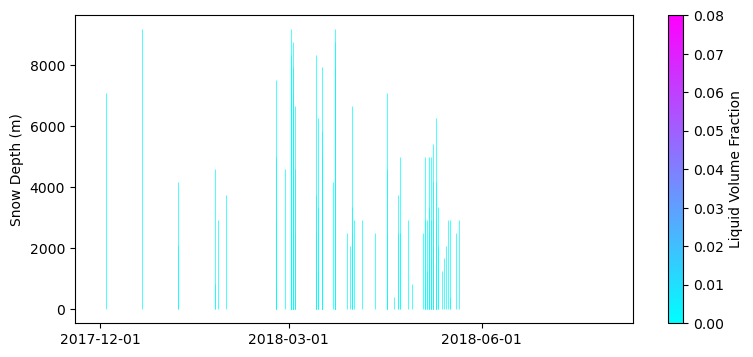

In [45]:
import pandas as pd
ds_plot = ds.sel(hru=1, time=slice(f"{years[1]-1}-12-01", f"{years[1]}-07-31")).resample(time='1D').mean()
fig, ax = plt.subplots(figsize=(9,4))
summa_layers_plot(ds_plot['mLayerVolFracLiq'], ds_plot['iLayerHeight'], 
                  variable_range=[0,0.08], 
                  colormap='cool', 
                  line_kwargs={'linewidth': 0.5},
                  cbar_kwargs={'label': 'Liquid Volume Fraction'},
                  plot_snow=True,
                  plot_soil=False,
                  ax=ax)
ax.set_ylabel('Snow Depth (m)')
ax.set_xticks(pd.date_range(start=f"{years[1]-1}-12-01", end=f"{years[1]}-07-31", freq='3MS'))


ValueError: Incorrect use of keyword argument 'rotation'. Keyword arguments other than 'minor' modify the text labels and can only be used if 'labels' are passed as well.

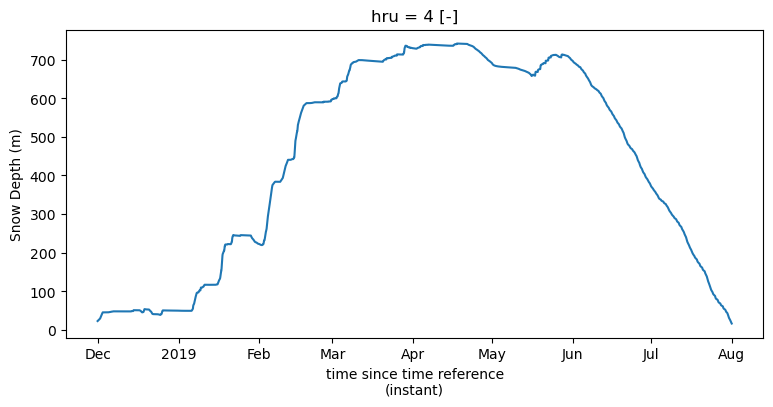

In [ ]:
fig, ax = plt.subplots(figsize=(9,4))
ds_plot['scalarSWE'].plot(ax=ax)

# ax.set_xticks(ax.get_xticks(), [pd.to_datetime(t).strftime('%Y-%m-%d') for t in ax.get_xticks()], rotation=45)

In [20]:
import pandas as pd

In [ ]:

plt.show()

/tmp/ipykernel_921610/1255442280.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig[0].set_xticklabels([pd.to_datetime(t).strftime('%Y-%m-%d') for t in fig[0].get_xticks()], rotation=45)


In [4]:
aso_flight_20180331 = rxr.open_rasterio("/scratch/dlhogan/ess-project-data/geospatial-data/ASO/ASO_50M_SWE_USCOGE_20180524.tif", masked=True).squeeze()

east_shapefile = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment/East_River_distributed_HRUs_elevation.shp")

result = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/lightweight/run_20260421_160220/results/base/SUMMA/light_20260421_160220_base_timestep.nc")

In [25]:
# mask aso
# average aso swe by hru 
aso_swe_by_hru = east_shapefile.set_index('HRU_ID').geometry.apply(lambda geom: aso_flight_20180331.rio.clip([geom], east_shapefile.crs).mean().item())*1000

# result swe for same time as aso flight
result_swe = result['scalarSWE'].resample(time='1D').mean().sel(time='2018-05-24').to_pandas()


In [26]:
# add to east shapefile
east_shapefile['ASO_SWE'] = east_shapefile['HRU_ID'].map(aso_swe_by_hru)
east_shapefile['SUMMA_SWE'] = east_shapefile['HRU_ID'].map(result_swe)

In [27]:
result_swe.sum()/aso_swe_by_hru.sum()

np.float64(1.2578029383700977)

Text(0.5, 1.0, 'SUMMA - ASO SWE on 2018-03-31')

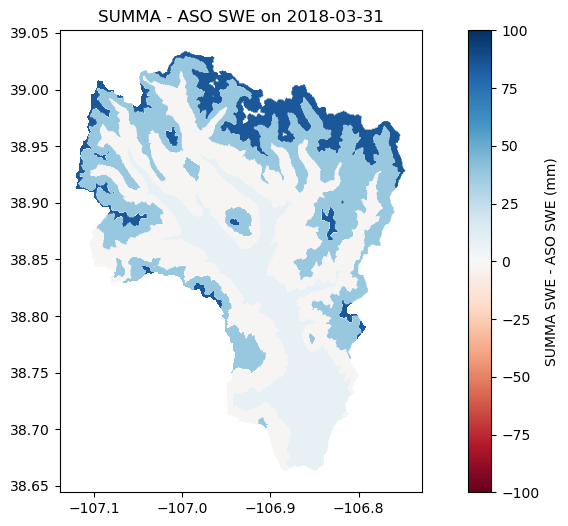

In [38]:
# plot map of aso swe and result swe by hru
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
east_shapefile.plot(column=result_swe-aso_swe_by_hru, ax=ax, legend=True, vmin=-100, vmax=100, cmap='RdBu', 
                    # add cmap label
                    legend_kwds={'label': "SUMMA SWE - ASO SWE (mm)"})
ax.set_title('SUMMA - ASO SWE on 2018-03-31')
# east_shapefile.plot(column=(result_swe), ax=ax[1], legend=True, vmin=0, vmax=500, cmap='Blues')
# ax[1].set_title('SUMMA SWE on 2018-03-31')
